# Full Dataset Training on CIFAR-10
## Models: MobileNetV2 & EfficientNet-B0

Objective:
Train both models on full dataset and compare performance.

## 1. Imports

In [1]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from torch.utils.data import Dataset, DataLoader

In [2]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2. Dataset - CIFAR-10



In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Training:", x_train.shape)
print("Testing:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training: (50000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


## Normalization

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).permute(0,3,1,2)
        self.labels = torch.tensor(labels, dtype=torch.long).squeeze()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

## DataLoader

In [6]:
trainset = CIFAR10Dataset(x_train, y_train)
testset = CIFAR10Dataset(x_test, y_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## 3. Loss Functions

In [7]:
criterion = nn.CrossEntropyLoss()

## 4. Train Function (With Validation)

In [8]:
def train_model(model, trainloader, testloader, optimizer, epochs):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

        t_loss = running_loss / len(trainloader)
        t_acc = 100 * correct / total

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                v_loss += loss.item()

                _, pred = torch.max(outputs, 1)
                v_total += labels.size(0)
                v_correct += (pred == labels).sum().item()

        v_loss /= len(testloader)
        v_acc = 100 * v_correct / v_total

        train_loss.append(t_loss)
        train_acc.append(t_acc)
        val_loss.append(v_loss)
        val_acc.append(v_acc)

        print(f"Epoch {epoch+1}: Train Acc={t_acc:.2f}% | Val Acc={v_acc:.2f}%")

    return train_loss, train_acc, val_loss, val_acc

## 5. Evaluation Function

In [9]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

## 6. MobileNet

## Model

In [10]:
model_mob = models.mobilenet_v2(weights="DEFAULT")
model_mob.classifier[1] = nn.Linear(1280, 10)
model_mob = model_mob.to(device)

optimizer_mob = optim.Adam(model_mob.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 134MB/s]


## Train

In [11]:
loss_mob, acc_mob, val_loss_mob, val_acc_mob = train_model(
    model_mob, trainloader, testloader, optimizer_mob, epochs=10
)

Epoch 1: Train Acc=63.34% | Val Acc=75.12%
Epoch 2: Train Acc=75.92% | Val Acc=78.31%
Epoch 3: Train Acc=79.70% | Val Acc=80.57%
Epoch 4: Train Acc=81.88% | Val Acc=81.83%
Epoch 5: Train Acc=83.31% | Val Acc=80.54%
Epoch 6: Train Acc=84.70% | Val Acc=82.21%
Epoch 7: Train Acc=86.46% | Val Acc=80.34%
Epoch 8: Train Acc=86.98% | Val Acc=82.28%
Epoch 9: Train Acc=88.16% | Val Acc=82.02%
Epoch 10: Train Acc=89.10% | Val Acc=82.68%


## Test Accuracy and Graph

MobileNet Test Accuracy: 82.68


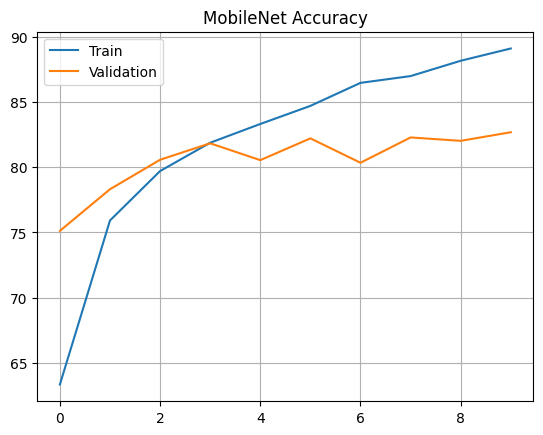

In [12]:
acc_mob_test = evaluate(model_mob, testloader)
print("MobileNet Test Accuracy:", acc_mob_test)

plt.plot(acc_mob, label="Train")
plt.plot(val_acc_mob, label="Validation")
plt.title("MobileNet Accuracy")
plt.legend()
plt.grid()
plt.show()

## Loss Graph

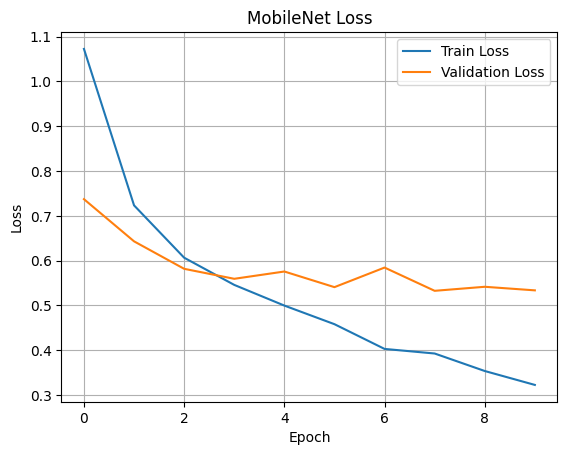

In [13]:
plt.plot(loss_mob, label="Train Loss")
plt.plot(val_loss_mob, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet Loss")
plt.legend()
plt.grid()

plt.show()

## Prediction

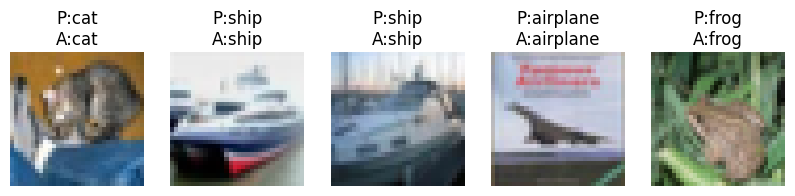

In [14]:
images, labels = next(iter(testloader))
images = images.to(device)

outputs = model_mob(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis("off")

plt.show()

## 7. EfficientNet

## Model

In [15]:
model_eff = models.efficientnet_b0(weights="DEFAULT")
model_eff.classifier[1] = nn.Linear(1280, 10)
model_eff = model_eff.to(device)

optimizer_eff = optim.Adam(model_eff.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 111MB/s] 


## Train

In [16]:
loss_eff, acc_eff, val_loss_eff, val_acc_eff = train_model(
    model_eff, trainloader, testloader, optimizer_eff, epochs=10
)

Epoch 1: Train Acc=65.23% | Val Acc=77.82%
Epoch 2: Train Acc=78.55% | Val Acc=81.50%
Epoch 3: Train Acc=82.22% | Val Acc=81.83%
Epoch 4: Train Acc=84.96% | Val Acc=83.46%
Epoch 5: Train Acc=86.68% | Val Acc=82.81%
Epoch 6: Train Acc=88.08% | Val Acc=83.53%
Epoch 7: Train Acc=89.75% | Val Acc=84.11%
Epoch 8: Train Acc=90.70% | Val Acc=84.17%
Epoch 9: Train Acc=91.59% | Val Acc=83.88%
Epoch 10: Train Acc=92.50% | Val Acc=84.11%


## Test Accuracy and Graph

EfficientNet Test Accuracy: 84.11


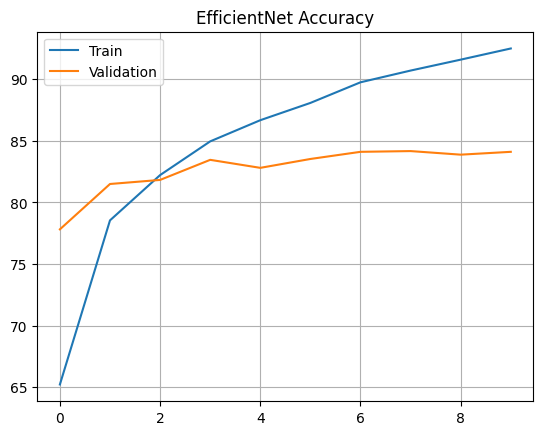

In [17]:
acc_eff_test = evaluate(model_eff, testloader)
print("EfficientNet Test Accuracy:", acc_eff_test)

plt.plot(acc_eff, label="Train")
plt.plot(val_acc_eff, label="Validation")
plt.title("EfficientNet Accuracy")
plt.legend()
plt.grid()
plt.show()

## Loss Graph

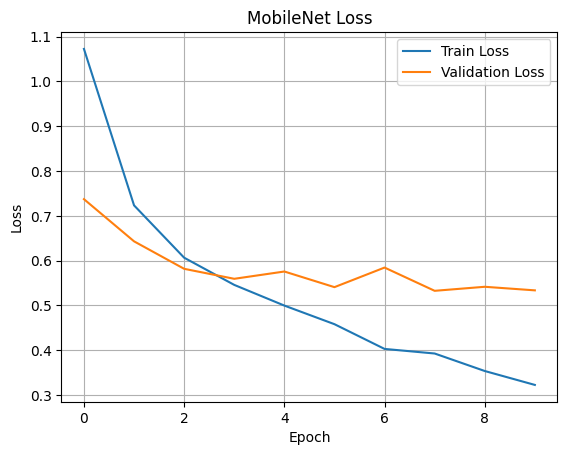

In [18]:
plt.plot(loss_mob, label="Train Loss")
plt.plot(val_loss_mob, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet Loss")
plt.legend()
plt.grid()

plt.show()

## Prediction

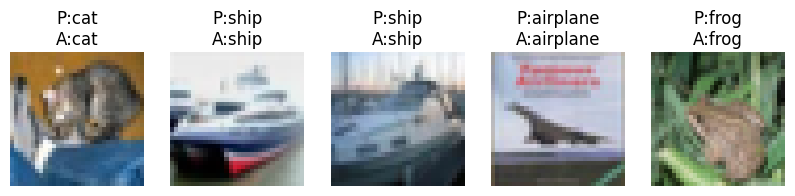

In [19]:
images, labels = next(iter(testloader))
images = images.to(device)

outputs = model_eff(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis("off")

plt.show()

## Final Accuracy

In [20]:
print("\nFinal Comparison:")
print(f"MobileNet Accuracy: {acc_mob_test:.2f}%")
print(f"EfficientNet Accuracy: {acc_eff_test:.2f}%")


Final Comparison:
MobileNet Accuracy: 82.68%
EfficientNet Accuracy: 84.11%
